<a href="https://colab.research.google.com/github/Alvaroort21/Paseo-aleatorio-simple/blob/main/PAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PASEO ALEATORIO SIMPLE EN PYTHON**

Función que devuelve los paseos queridos en las filas de una matriz:



In [103]:
import numpy as np
import matplotlib.pyplot as plt
def simularPAS(p,reps,n):
  rng=np.random.default_rng()
  x=rng.binomial(1,p,size=(reps, n-1))          #genera una Bernuilli
  y=2*x-1                                       #transforma la bernuilli en los Z_s
  paseo = np.cumsum(y, axis=1)                  #genera el paseo por filas
  paseo=np.insert(paseo, 0, 0, axis=1)          #insertamos columnas de cero para que todos los paseos empiezen desde 0
  return paseo
#p es la probabilidad de tomar el valor 1 en cada paso del PAS, tomada entre 0 y 1
#reps es el número de paseos a simular
#n es el número de pasos que se simulan en cada paseo
#La función devuelve una matriz con reps filas y n columnas. Cada fila representa un paseo con tantas columnas como pasos de este


Creamos las funciones para calcualr las medias y varianzas

In [104]:
def media_teorica(p,n):
  media=np.full(n, 2*p-1)*np.array(list(range(0,n)))
  return media   #crea  una lista con la esperenza de cada X_n

In [105]:
def dt_teorica(p,n):
  var=np.full(n, 4*p*(1-p))*np.array(list(range(0,n)))
  return np.sqrt(var)   #crea  una lista con la varianza de cada X_n

In [106]:
def media_emp(paseo):
  media=np.mean(paseo, axis=0)  #media por columnas de la matriz
  return(media)  #devuelve un array de np con la media por columnas de la matriz del paseo


Creamos una función para graficar los PAS (sin media ni varianza):

In [107]:
def graficarPAS(p,n,reps):
  paseo=simularPAS(p,reps,n)  #creamos la matriz del PAS
  absc=np.arange(n)  #abcisas para gráficar los PAS
  plt.plot(absc, paseo.T, linestyle="-")   #grafica todos los PAS
  plt.title(f"Simulación de {reps} PAS con {n} pasos (p={p})")
  plt.show()
#Esta función grafica reps PAS de probabilidad p con n pasos en cada uno

Función para graficar PAS con media y varianza:

In [108]:
def graficarPAS_media(p,n,reps):
  paseo=simularPAS(p,reps,n)  #creamos la matriz del PAS
  absc=np.arange(n)  #abcisas para gráficar los PAS
  media_t=media_teorica(p,n)  #guarda la media teórica
  dt_t=dt_teorica(p,n)        #guarda la desviación típica teórica
  plt.plot(absc, paseo.T, linestyle="-")   #grafica todos los PAS
  plt.plot(absc,media_t, color='black', linestyle='--', linewidth=1,label="Media teorica")  #muestra la media teórica

  plt.plot(absc, media_t+2*dt_t,color="blue" ,linestyle='-', linewidth=1,label=r'$\pm 2 \sigma$')
  plt.plot(absc, media_t-2*dt_t,color="blue" ,linestyle='-', linewidth=1)
  plt.fill_between(absc, media_t-2*dt_t, media_t+2*dt_t,alpha=0.15)    #Muestra un entorno alrededor de dos desviaciín típica

  plt.plot(absc, media_t+dt_t,color="black" ,linestyle='-', linewidth=1,label=r'$\pm 1 \sigma$')
  plt.plot(absc, media_t-dt_t,color="black" ,linestyle='-', linewidth=1)
  plt.fill_between(absc, media_t-dt_t,media_t+dt_t,alpha=0.35)     #Muestra un entorno alrededor de una desviación típica

  plt.legend()
  plt.title(f"Simulación de {reps} PAS con {n} pasos (p={p})")
  plt.show()
  #Esta función grafica reps PAS de probabilidad p con n pasos en cada uno junto con la media teórica y uno y dos entornos de la dt

Función para graficar la media empírica frente a la teórica

---



In [109]:
def graficar_media_emp(n,p):
  absc=np.arange(n)
  plt.plot(absc, media_teorica(p,n), color='black', linestyle='-', linewidth=1,label="Media teorica")
  plt.plot(absc, media_emp(simularPAS(p,5,n)), linestyle='-', linewidth=1,label="5")
  plt.plot(absc, media_emp(simularPAS(p,100,n)), linestyle='-', linewidth=1,label="100")
  plt.plot(absc, media_emp(simularPAS(p,200,n)), linestyle='-', linewidth=1,label="200")
  plt.plot(absc, media_emp(simularPAS(p,500,n)),  linestyle='-', linewidth=1,label="500")
  plt.plot(absc, media_emp(simularPAS(p,1000,n)), linestyle='-', linewidth=1,label="1000")

  plt.legend()
  plt.title(f"Media empírica contra teórica de distintos PAS con {n} pasos (p={p})")
  plt.show()

#La función grafica la media teórica y la empírica de distintos PAs con n pasos cada uno

Creamos las gráficas:

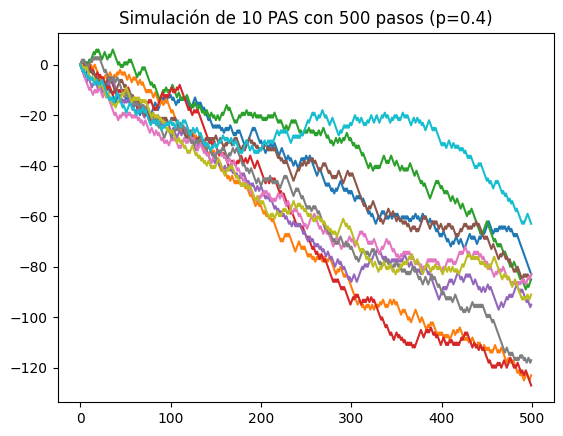

In [110]:
graficarPAS(0.4,500,10)

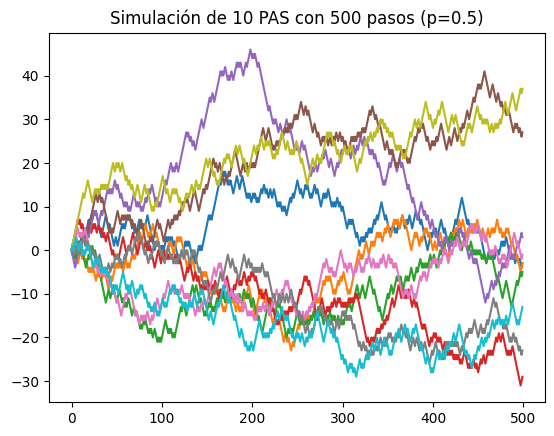

In [111]:
graficarPAS(0.5,500,10)

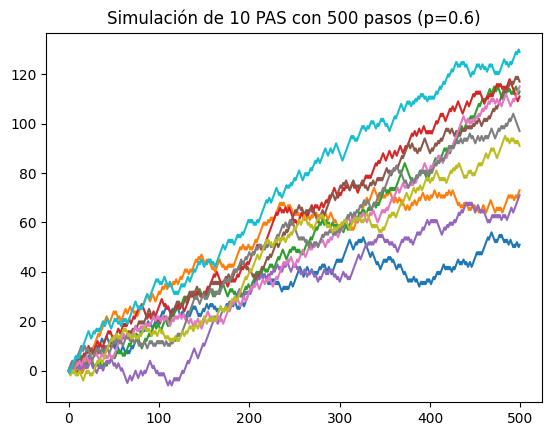

In [112]:
graficarPAS(0.6,500,10)

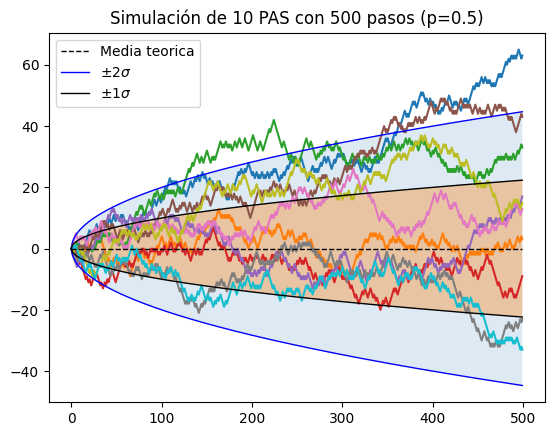

In [113]:
graficarPAS_media(0.5,500,10)

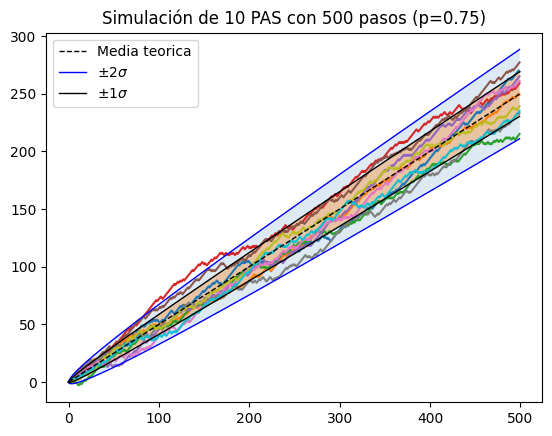

In [114]:
graficarPAS_media(0.75,500,10)

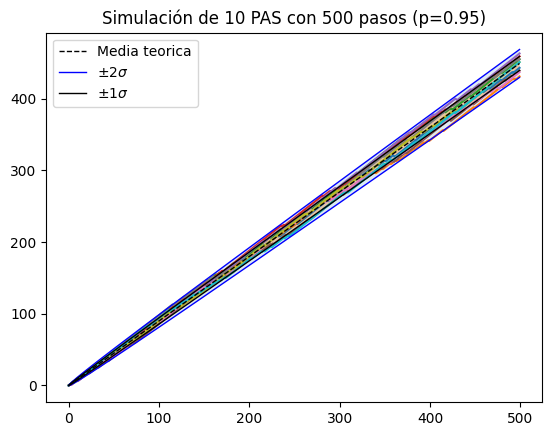

In [115]:
graficarPAS_media(0.95,500,10)

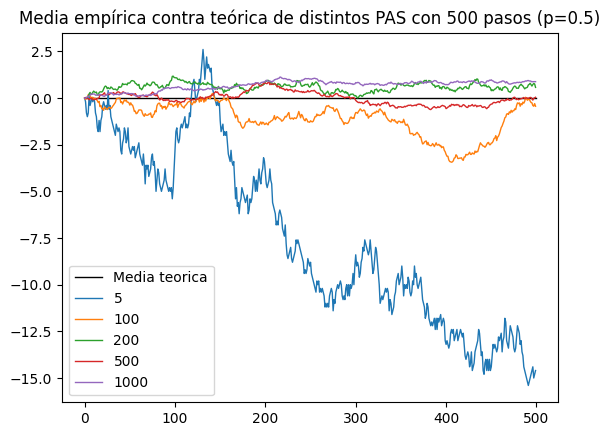

In [116]:
graficar_media_emp(500,0.5)